In [1]:
import pandas as pd

df = pd.read_csv('data/raw/daily_88101_2023.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(847370, 29)
['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']
   State Code  County Code  Site Num  Parameter Code  POC   Latitude  \
0           1            3        10           88101    3  30.497478   
1           1            3        10           88101    3  30.497478   
2           1            3        10           88101    3  30.497478   
3           1            3        10           88101    3  30.497478   
4           1            3        10           88101    3  30.497478   

   Longitude  Datum            Parameter Name Sample Duration  ... AQI  \
0 -87.880258  NAD83  PM2.5 - Lo

In [2]:
la_df = df[df['State Name'] == 'California']
print(la_df['County Name'].unique())

['Alameda' 'Butte' 'Calaveras' 'Colusa' 'Contra Costa' 'Fresno' 'Humboldt'
 'Imperial' 'Inyo' 'Kern' 'Kings' 'Lake' 'Los Angeles' 'Madera' 'Marin'
 'Mendocino' 'Merced' 'Mono' 'Monterey' 'Nevada' 'Orange' 'Placer'
 'Plumas' 'Riverside' 'Sacramento' 'San Benito' 'San Bernardino'
 'San Diego' 'San Francisco' 'San Joaquin' 'San Luis Obispo' 'San Mateo'
 'Santa Barbara' 'Santa Clara' 'Santa Cruz' 'Shasta' 'Siskiyou' 'Solano'
 'Sonoma' 'Stanislaus' 'Sutter' 'Tehama' 'Tulare' 'Ventura' 'Yolo']


In [3]:
la_df = df[(df['State Name'] == 'California') & (df['County Name'] == 'Los Angeles')]

print(la_df.shape)
print(la_df.columns.tolist())
print(la_df.head())

(4383, 29)
['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']
       State Code  County Code  Site Num  Parameter Code  POC  Latitude  \
55522           6           37      1103           88101    1  34.06659   
55523           6           37      1103           88101    1  34.06659   
55524           6           37      1103           88101    1  34.06659   
55525           6           37      1103           88101    1  34.06659   
55526           6           37      1103           88101    1  34.06659   

       Longitude  Datum            Parameter Name Sample Duration  ...   AQI  \
55522 -11

In [4]:
for col in la_df.columns.tolist():
    print(col)

State Code
County Code
Site Num
Parameter Code
POC
Latitude
Longitude
Datum
Parameter Name
Sample Duration
Pollutant Standard
Date Local
Units of Measure
Event Type
Observation Count
Observation Percent
Arithmetic Mean
1st Max Value
1st Max Hour
AQI
Method Code
Method Name
Local Site Name
Address
State Name
County Name
City Name
CBSA Name
Date of Last Change


In [5]:
print(la_df['CBSA Name'].unique())
print(la_df['City Name'].unique())

['Los Angeles-Long Beach-Anaheim, CA']
['Los Angeles' 'Reseda' 'Compton' 'Pico Rivera' 'Pasadena' 'Long Beach'
 'Signal Hill' 'Lancaster']


In [6]:
central_la = la_df[la_df['City Name'] == 'Los Angeles']
print(central_la.shape)
print(central_la['Local Site Name'].unique())

(1134, 29)
['Los Angeles-North Main Street']


In [7]:
print(central_la['Sample Duration'].value_counts())
print(central_la['Pollutant Standard'].value_counts())

Sample Duration
24 HOUR          410
1 HOUR           363
24-HR BLK AVG    361
Name: count, dtype: int64
Pollutant Standard
PM25 24-hour 2012    771
Name: count, dtype: int64


In [8]:
daily_la = central_la[central_la['Sample Duration'] == '24 HOUR']

print(daily_la.shape)
print(daily_la['Date Local'].nunique())
print(daily_la[['Date Local', 'AQI']].head(10))

(410, 29)
354
      Date Local   AQI
55522   1/1/2023  20.0
55523   1/2/2023  48.0
55524   1/3/2023  26.0
55525   1/4/2023  24.0
55526   1/5/2023  34.0
55527   1/6/2023  52.0
55528   1/7/2023  52.0
55529   1/8/2023  61.0
55530   1/9/2023  35.0
55531  1/10/2023  29.0


In [9]:
# find a date that appears more than once
dupes = daily_la[daily_la.duplicated(subset='Date Local', keep=False)]
print(dupes[['Date Local', 'AQI', 'Pollutant Standard', 'Method Name']].head(10))

      Date Local   AQI Pollutant Standard  \
55527   1/6/2023  52.0  PM25 24-hour 2012   
55533  1/12/2023  36.0  PM25 24-hour 2012   
55539  1/18/2023  39.0  PM25 24-hour 2012   
55545  1/24/2023  44.0  PM25 24-hour 2012   
55551  1/30/2023  27.0  PM25 24-hour 2012   
55557   2/5/2023  58.0  PM25 24-hour 2012   
55562  2/11/2023  42.0  PM25 24-hour 2012   
55568  2/17/2023  35.0  PM25 24-hour 2012   
55574  2/23/2023  21.0  PM25 24-hour 2012   
55580   3/1/2023   9.0  PM25 24-hour 2012   

                                             Method Name  
55527  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55533  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55539  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55545  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55551  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55557  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55562  R & P Model 2025 PM-2.5 Sequential Air Sampler...  
55568  R & P Model 2025 PM-2.5 S

In [10]:
print(daily_la[daily_la['Date Local'] == '1/6/2023'][['Date Local', 'AQI', 'Method Name', 'Arithmetic Mean']])

      Date Local   AQI                                        Method Name  \
55527   1/6/2023  52.0  R & P Model 2025 PM-2.5 Sequential Air Sampler...   
55874   1/6/2023  54.0  R & P Model 2025 PM-2.5 Sequential Air Sampler...   

       Arithmetic Mean  
55527              9.9  
55874             10.5  


In [11]:
# take the max AQI per day to match AirNow reporting methodology
daily_la_clean = daily_la.groupby('Date Local')['AQI'].max().reset_index()

print(daily_la_clean.shape)
print(daily_la_clean.head(10))

(354, 2)
  Date Local   AQI
0   1/1/2023  20.0
1  1/10/2023  29.0
2  1/11/2023  55.0
3  1/12/2023  37.0
4  1/13/2023  51.0
5  1/14/2023  56.0
6  1/15/2023  31.0
7  1/16/2023  17.0
8  1/17/2023  21.0
9  1/18/2023  41.0


In [12]:
from epa_loader import load_epa_year, load_all_years

df_all = load_all_years('data/raw')

print(df_all.shape)
print(df_all['Date Local'].min())
print(df_all['Date Local'].max())
print(df_all.isnull().sum())

(1796, 2)
2020-01-01 00:00:00
2024-12-31 00:00:00
Date Local    0
AQI           0
dtype: int64


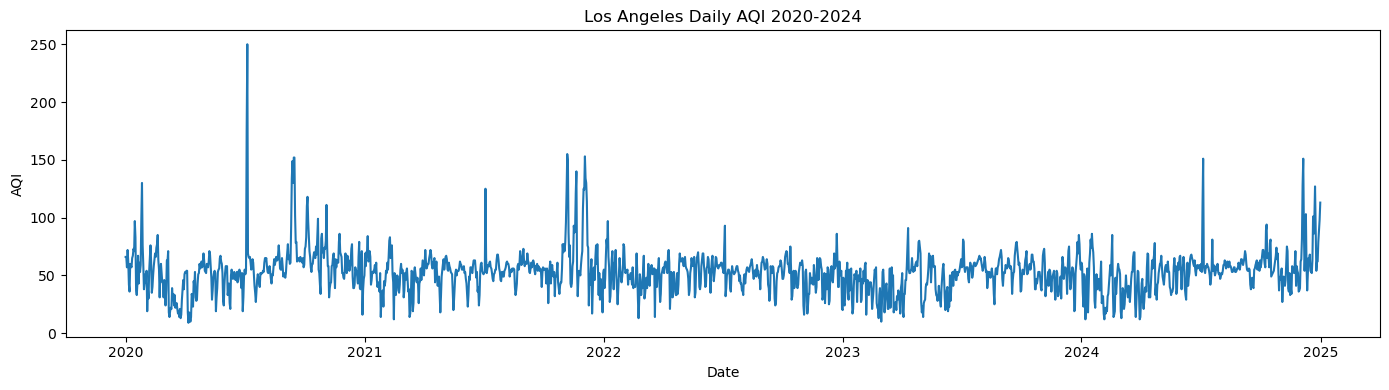

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_all['Date Local'], df_all['AQI'])
plt.title('Los Angeles Daily AQI 2020-2024')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

In [14]:
# LA coordinates and weather variables we want
LA_LAT = 34.0549
LA_LON = -118.2426
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

WWEATHER_VARIABLES = [
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "winddirection_10m_dominant",
    "pressure_msl_mean",
    "dewpoint_2m_max",
    "cloudcover_mean"
]

In [15]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": LA_LAT,
    "longitude": LA_LON,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "daily": ",".join(WEATHER_VARIABLES),
    "timezone": "America/Los_Angeles"
}

response = requests.get(url, params=params)
print(response.status_code)
print(response.json().keys())

NameError: name 'WEATHER_VARIABLES' is not defined

In [ ]:
import pandas as pd

weather_json = response.json()
weather_df = pd.DataFrame(weather_json['daily'])

print(weather_df.shape)
print(weather_df.head())
print(weather_df.isnull().sum())

In [ ]:
# rename weather date column to match AQI
weather_df = weather_df.rename(columns={'time': 'Date Local'})

# convert to datetime to match AQI dataframe
weather_df['Date Local'] = pd.to_datetime(weather_df['Date Local'])

# merge
df_merged = pd.merge(df_all, weather_df, on='Date Local', how='inner')

print(df_merged.shape)
print(df_merged.head())
print(df_merged.isnull().sum())

In [ ]:
df_merged.to_csv('data/processed/LA_weather_aqi.csv', index=False)

In [ ]:
import pandas as pd

df = pd.read_csv('data/processed/LA_weather_aqi.csv', parse_dates=['Date Local'])

print(df.shape)
print(df.dtypes)
print(df.head())



In [ ]:
import pandas as pd
df_check = pd.read_csv('data/processed/LA_weather_aqi.csv')
print(df_check.columns.tolist())
print(df_check.shape)

In [ ]:
import os
print(os.listdir('data/processed/'))

In [ ]:
df_check = pd.read_csv('data/processed/LA_weather_aqi.csv')
print(df_check.columns.tolist())
print(df_check.shape)

In [ ]:
# Load ozone data for LA
import pandas as pd
ozone_df = pd.read_csv('data/raw/daily_44201_2023.csv')

# Filter to LA same as before
la_ozone = ozone_df[
    (ozone_df['State Name'] == 'California') &
    (ozone_df['County Name'] == 'Los Angeles') &
    (ozone_df['City Name'] == 'Los Angeles')
]

# Get daily max ozone AQI
la_ozone_daily = la_ozone.groupby('Date Local')['AQI'].max().reset_index()
la_ozone_daily.columns = ['Date Local', 'ozone_aqi']
la_ozone_daily['Date Local'] = pd.to_datetime(la_ozone_daily['Date Local'])

print(la_ozone_daily.shape)
print(la_ozone_daily.head())

In [ ]:
import pandas as pd
from epa_loader import load_all_years, load_all_ozone_years

pm25_daily = load_all_years('data/raw')
pm25_daily = pm25_daily.rename(columns={'AQI': 'pm25_aqi'})

ozone_daily = load_all_ozone_years('data/raw')

combined = pd.merge(pm25_daily, ozone_daily, on='Date Local', how='inner')
combined['AQI'] = combined[['pm25_aqi', 'ozone_aqi']].max(axis=1)
combined = combined.sort_values('Date Local').reset_index(drop=True)

combined.to_csv('data/processed/LA_weather_aqi.csv', index=False)

print(combined.shape)
print(combined.head())

In [ ]:
final = pd.merge(combined, weather_df, on='Date Local', how='inner')
final.to_csv('data/processed/LA_weather_aqi.csv', index=False)

print(final.shape)
print(final.columns.tolist())

In [ ]:
# Load your PM2.5 data
pm25_daily = daily_la_clean.copy()
pm25_daily['Date Local'] = pd.to_datetime(pm25_daily['Date Local'])
pm25_daily.columns = ['Date Local', 'pm25_aqi']

# Merge both
comparison = pd.merge(pm25_daily, la_ozone_daily, on='Date Local', how='inner')

# Filter to April only
april = comparison[comparison['Date Local'].dt.month == 4]

# Compare which is higher
april = april.copy()
april['dominant'] = april.apply(
    lambda x: 'ozone' if x['ozone_aqi'] > x['pm25_aqi'] else 'pm25', axis=1
)

print(april['dominant'].value_counts())
print(f"\nOzone dominates {(april['dominant']=='ozone').mean()*100:.1f}% of April days")
print(april[['Date Local', 'pm25_aqi', 'ozone_aqi', 'dominant']].to_string())